# Factor Zoo Validation via Post-Double-Selection LASSO

**Chapter 15: Causal Machine Learning**

This notebook uses post-double-selection LASSO to ask whether managed-portfolio
factor returns add incremental time-series explanatory power for SPY after ten
principal-component controls. It is a compact factor-spanning application of the
Belloni-Chernozhukov-Hansen selection logic discussed in this chapter.

## Learning objectives

- distinguish a naive single-factor association from a conditional factor loading;
- implement both LASSO selections with time-ordered cross-validation;
- carry the selected union into an intercept-inclusive OLS regression with HAC inference;
- interpret what the exercise does and does not establish about the factor zoo.

**Book references**: Chapter 14, Section 14.5 (Taming the Factor Zoo), and
Chapter 15, Section 15.3 (Double Machine Learning).

**Prerequisites**: [`01_pca_equity_sectors`](../14_latent_factors/01_pca_equity_sectors.ipynb)
and [`03_econml_dml`](03_econml_dml.ipynb).

## Setup

The ETF data are daily, so the cube-root Newey-West bandwidth provides a transparent
default for serial dependence. The bandwidth is computed after the 60-day warm-up.

In [1]:
"""Factor-spanning validation with post-double-selection LASSO."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title, zero_line

warnings.filterwarnings("ignore")

In [2]:
START_DATE = "2006-01-01"
END_DATE = "2024-12-31"
MIN_OBSERVATIONS = 252
N_PCA_FACTORS = 10
N_CV_SPLITS = 5
N_ALPHAS = 60
SIGNIFICANCE_LEVEL = 0.05
MAX_SYMBOLS = 0  # 0 = all eligible symbols
OUTCOME_SYMBOL = "SPY"
WARMUP = 60
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. Build a balanced, disjoint ETF panel

SPY is excluded from the factor-building universe and retained only as the outcome.
The source contains ETFs with different inception dates. Replacing pre-inception
observations with zero would manufacture returns, so the analysis retains the
long-history symbols observed on every date in the requested sample.

This eligibility rule uses the current curated ETF list and is not a point-in-time
historical universe. The result is an in-sample teaching exercise, not a
survivorship-free backtest or a sealed holdout estimate.

In [4]:
etf_data = load_etfs(start_date=START_DATE, end_date=END_DATE).sort(["symbol", "timestamp"])

duplicate_keys = etf_data.select(pl.struct("symbol", "timestamp").is_duplicated().sum()).item()
if duplicate_keys:
    raise ValueError(f"ETF input contains {duplicate_keys} duplicate symbol-timestamp keys")

etf_returns = etf_data.with_columns(
    pl.col("close").pct_change().over("symbol").alias("return")
).drop_nulls(subset=["return"])

n_source_dates = etf_returns["timestamp"].n_unique()
symbol_coverage = etf_returns.group_by("symbol").len().sort("symbol")
eligible_symbols = symbol_coverage.filter(
    (pl.col("len") == n_source_dates) & (pl.col("len") >= MIN_OBSERVATIONS)
)["symbol"].to_list()

if OUTCOME_SYMBOL not in eligible_symbols:
    raise ValueError(f"Outcome {OUTCOME_SYMBOL!r} lacks complete sample coverage")
if MAX_SYMBOLS > 0:
    eligible_symbols = eligible_symbols[:MAX_SYMBOLS]
    if OUTCOME_SYMBOL not in eligible_symbols:
        eligible_symbols.append(OUTCOME_SYMBOL)

Pivoting after the coverage filter produces a genuinely balanced panel. The null
and finite-value assertions make the no-imputation contract executable.

In [5]:
return_wide = (
    etf_returns.filter(pl.col("symbol").is_in(eligible_symbols))
    .pivot(on="symbol", index="timestamp", values="return")
    .sort("timestamp")
)

symbols_all = [column for column in return_wide.columns if column != "timestamp"]
if len(symbols_all) <= N_PCA_FACTORS + 1:
    raise ValueError("The balanced universe is too small for the requested PCA basis")
if return_wide.select(pl.sum_horizontal(pl.exclude("timestamp").null_count())).item() != 0:
    raise ValueError("Balanced return panel contains missing values")

returns_all = return_wide.select(symbols_all).to_numpy().astype(np.float64)
if not np.isfinite(returns_all).all():
    raise ValueError("Balanced return panel contains non-finite values")

outcome_idx = symbols_all.index(OUTCOME_SYMBOL)
outcome_return = returns_all[:, outcome_idx]
zoo_mask = np.ones(returns_all.shape[1], dtype=bool)
zoo_mask[outcome_idx] = False
zoo_returns = returns_all[:, zoo_mask]
zoo_symbols = [symbol for symbol in symbols_all if symbol != OUTCOME_SYMBOL]
T, N = zoo_returns.shape

print(
    f"Analysis window: {return_wide['timestamp'].min()} to {return_wide['timestamp'].max()} "
    f"({T:,} trading days)"
)
print(f"Outcome: {OUTCOME_SYMBOL}; factor-building universe: {N} long-history ETFs")
print("Missing returns imputed: 0")

Analysis window: 2006-01-04 to 2024-12-31 (4,780 trading days)
Outcome: SPY; factor-building universe: 58 long-history ETFs
Missing returns imputed: 0


## 2. Extract principal-component controls

Standardization prevents high-volatility ETFs from dominating the covariance
structure. The final basis is fitted on the full post-warm-up inference sample
because these are explicitly in-sample controls; uncertainty is conditional on
this estimated basis. Selection below refits both transformations inside each fold.

In [6]:
pca_scaler = StandardScaler()
zoo_returns_inference = zoo_returns[WARMUP:]
zoo_returns_scaled = pca_scaler.fit_transform(zoo_returns_inference)
pca = PCA(n_components=N_PCA_FACTORS, random_state=SEED)
factor_returns = pca.fit_transform(zoo_returns_scaled)

factor_names = [f"PC{i + 1}" for i in range(N_PCA_FACTORS)]
variance_table = pl.DataFrame(
    {
        "factor": factor_names,
        "variance_explained": pca.explained_variance_ratio_,
        "cumulative_variance": np.cumsum(pca.explained_variance_ratio_),
    }
).with_columns(pl.selectors.numeric().round(4))

print(
    f"Cumulative variance explained by {N_PCA_FACTORS} PCs: {pca.explained_variance_ratio_.sum():.1%}"
)
variance_table

Cumulative variance explained by 10 PCs: 88.8%


factor,variance_explained,cumulative_variance
str,f64,f64
"""PC1""",0.6305,0.6305
"""PC2""",0.0795,0.71
"""PC3""",0.0458,0.7558
"""PC4""",0.0287,0.7845
"""PC5""",0.0254,0.8099
"""PC6""",0.0242,0.8341
"""PC7""",0.0186,0.8527
"""PC8""",0.0151,0.8678
"""PC9""",0.0107,0.8785


## 3. Construct lagged managed-portfolio factors

Each portfolio uses information ending at $t-1$ to set long and short baskets,
then records their return at $t$. The four candidates differ only in the ranking
statistic and lookback window.

In [7]:
momentum_20d = np.zeros(T)
for t in range(20, T):
    momentum = zoo_returns[t - 20 : t].sum(axis=0)
    top = momentum >= np.percentile(momentum, 80)
    bottom = momentum <= np.percentile(momentum, 20)
    momentum_20d[t] = zoo_returns[t, top].mean() - zoo_returns[t, bottom].mean()

momentum_60d = np.zeros(T)
for t in range(60, T):
    momentum = zoo_returns[t - 60 : t].sum(axis=0)
    top = momentum >= np.percentile(momentum, 80)
    bottom = momentum <= np.percentile(momentum, 20)
    momentum_60d[t] = zoo_returns[t, top].mean() - zoo_returns[t, bottom].mean()

Low-volatility and mean-reversion portfolios reverse the ranking direction: they
buy the low-volatility or recent-loser quintile and sell the opposite quintile.

In [8]:
low_vol = np.zeros(T)
for t in range(60, T):
    volatility = zoo_returns[t - 60 : t].std(axis=0)
    low = volatility <= np.percentile(volatility, 20)
    high = volatility >= np.percentile(volatility, 80)
    low_vol[t] = zoo_returns[t, low].mean() - zoo_returns[t, high].mean()

mean_reversion = np.zeros(T)
for t in range(5, T):
    recent_return = zoo_returns[t - 5 : t].sum(axis=0)
    losers = recent_return <= np.percentile(recent_return, 20)
    winners = recent_return >= np.percentile(recent_return, 80)
    mean_reversion[t] = zoo_returns[t, losers].mean() - zoo_returns[t, winners].mean()

The common warm-up removes the initialized zeros before any inference. Annualized
Sharpe ratios here are descriptive summaries, not selection criteria.

In [9]:
candidate_names = ["Mom_20d", "Mom_60d", "LowVol", "MeanRev"]
candidates = np.column_stack([momentum_20d, momentum_60d, low_vol, mean_reversion])[WARMUP:]
outcome_trimmed = outcome_return[WARMUP:]
controls_trimmed = factor_returns
HAC_LAGS = max(1, int(len(outcome_trimmed) ** (1 / 3)))

candidate_summary = pl.DataFrame(
    {
        "factor": candidate_names,
        "annualized_sharpe": [
            candidates[:, i].mean() / candidates[:, i].std(ddof=1) * np.sqrt(252)
            for i in range(len(candidate_names))
        ],
        "daily_volatility": [candidates[:, i].std(ddof=1) for i in range(len(candidate_names))],
    }
).with_columns(pl.selectors.numeric().round(4))

print(f"Inference sample: {len(outcome_trimmed):,} days; Newey-West bandwidth: {HAC_LAGS} lags")
candidate_summary

Inference sample: 4,720 days; Newey-West bandwidth: 16 lags


factor,annualized_sharpe,daily_volatility
str,f64,f64
"""Mom_20d""",-0.3373,0.0123
"""Mom_60d""",-0.3678,0.0125
"""LowVol""",-0.2059,0.0155
"""MeanRev""",0.8636,0.0125


## 4. Match the naive and conditional estimands

A factor-mean test and a regression loading answer different questions. The
comparison below holds the target fixed: the naive slope comes from SPY on one
candidate, while the post-selection slope adds selected PCA controls. Both models
include an intercept and use the same Newey-West covariance estimator.

In [10]:
def ols_hac_test(outcome: np.ndarray, design: np.ndarray, hac_lags: int) -> dict[str, float]:
    """Estimate the first slope in an intercept-inclusive OLS-HAC regression."""
    design_2d = design.reshape(-1, 1) if design.ndim == 1 else design
    model = sm.OLS(outcome, sm.add_constant(design_2d)).fit(
        cov_type="HAC", cov_kwds={"maxlags": hac_lags}
    )
    return {
        "coef": float(model.params[1]),
        "se": float(model.bse[1]),
        "t_stat": float(model.tvalues[1]),
        "p_value": float(model.pvalues[1]),
    }

In [11]:
naive_results = []
for index, name in enumerate(candidate_names):
    result = ols_hac_test(outcome_trimmed, candidates[:, index], HAC_LAGS)
    naive_results.append({"factor": name, **result})

naive_table = pl.DataFrame(naive_results).with_columns(
    pl.col("coef", "se").round(4),
    pl.col("t_stat").round(2),
    pl.col("p_value").round(4),
)
naive_table

factor,coef,se,t_stat,p_value
str,f64,f64,f64,f64
"""Mom_20d""",-0.4011,0.0818,-4.9,0.0
"""Mom_60d""",-0.403,0.0806,-5.0,0.0
"""LowVol""",-0.6898,0.0186,-37.05,0.0
"""MeanRev""",0.2875,0.0573,5.01,0.0


## 5. Select controls without leaking future folds

Each LASSO uses an expanding time-series split. Its pipeline refits the input
scaler, PCA basis, and control scaler on each training fold, so later observations
cannot change an earlier validation prediction. A fixed broad alpha grid avoids
using the full target series to calibrate the candidate penalties.

In [12]:
def fit_lasso_selector(target: np.ndarray, pca_inputs: np.ndarray) -> dict:
    """Tune a fold-local PCA-LASSO pipeline and return its full-sample support."""
    alpha_grid = np.geomspace(1e-8, 1e-2, N_ALPHAS)
    pipeline = make_pipeline(
        StandardScaler(),
        PCA(n_components=N_PCA_FACTORS, random_state=SEED),
        StandardScaler(),
        Lasso(max_iter=20_000, random_state=SEED),
    )
    search = GridSearchCV(
        pipeline,
        {"lasso__alpha": alpha_grid},
        cv=TimeSeriesSplit(n_splits=N_CV_SPLITS),
        scoring="neg_mean_squared_error",
        n_jobs=-1,
    )
    search.fit(pca_inputs, target)
    coefficients = search.best_estimator_.named_steps["lasso"].coef_
    return {
        "selected": np.flatnonzero(np.abs(coefficients) > 1e-10),
        "alpha": float(search.best_params_["lasso__alpha"]),
    }

The first selection finds PCA controls that explain SPY. The second finds PCA
controls related to the candidate. Their union protects the candidate slope from
controls that one predictive equation alone might omit.

In [13]:
def double_selection_test(
    outcome: np.ndarray,
    candidate: np.ndarray,
    controls: np.ndarray,
    pca_inputs: np.ndarray,
    control_names: list[str],
    hac_lags: int,
) -> dict:
    """Run post-double-selection and HAC inference for one candidate slope."""
    outcome_selection = fit_lasso_selector(outcome, pca_inputs)
    candidate_selection = fit_lasso_selector(candidate, pca_inputs)
    selected_union = sorted(
        set(outcome_selection["selected"]) | set(candidate_selection["selected"])
    )

    final_design = candidate.reshape(-1, 1)
    if selected_union:
        final_design = np.column_stack([candidate, controls[:, selected_union]])
    inference = ols_hac_test(outcome, final_design, hac_lags)

    return {
        **inference,
        "n_outcome": len(outcome_selection["selected"]),
        "n_candidate": len(candidate_selection["selected"]),
        "n_union": len(selected_union),
        "outcome_alpha": outcome_selection["alpha"],
        "candidate_alpha": candidate_selection["alpha"],
        "selected_names": [control_names[i] for i in selected_union],
    }

## 6. Run post-double-selection for the four candidates

In [14]:
post_results = []
for index, name in enumerate(candidate_names):
    result = double_selection_test(
        outcome_trimmed,
        candidates[:, index],
        controls_trimmed,
        zoo_returns_inference,
        factor_names,
        HAC_LAGS,
    )
    post_results.append({"factor": name, **result})

post_table = pl.DataFrame(post_results).select(
    "factor",
    pl.col("coef").round(4),
    pl.col("se").round(4),
    pl.col("t_stat").round(2),
    pl.col("p_value").round(4),
    "n_outcome",
    "n_candidate",
    "n_union",
)
post_table

factor,coef,se,t_stat,p_value,n_outcome,n_candidate,n_union
str,f64,f64,f64,f64,i64,i64,i64
"""Mom_20d""",-0.0073,0.0072,-1.01,0.3107,10,5,10
"""Mom_60d""",-0.0081,0.0094,-0.86,0.3924,10,1,10
"""LowVol""",-0.0055,0.013,-0.42,0.6737,10,7,10
"""MeanRev""",0.0029,0.0045,0.65,0.5168,10,2,10


## 7. Compare uncertainty and selection breadth

The left panel compares the same SPY loading before and after PCA conditioning;
error bars are Newey-West 95% intervals. The right panel shows how many of the ten
PCA controls enter the post-selection union.

In [15]:
factor_positions = np.arange(len(candidate_names))
naive_coef = np.array([result["coef"] for result in naive_results])
naive_se = np.array([result["se"] for result in naive_results])
post_coef = np.array([result["coef"] for result in post_results])
post_se = np.array([result["se"] for result in post_results])
union_size = np.array([result["n_union"] for result in post_results])
figure_subtitle = (
    f"HAC estimates; {N}-ETF factor zoo; {return_wide['timestamp'].min()} "
    f"to {return_wide['timestamp'].max()}"
)

The coefficient panel uses position and marker shape as well as color, so the
comparison remains legible in grayscale. The selection bars start at zero.

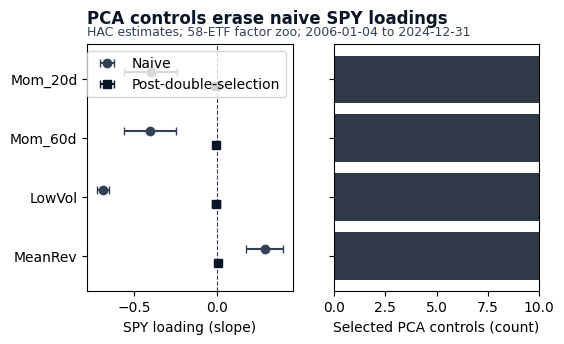

In [16]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE["dual_h_tall"], sharey=True)

axes[0].errorbar(
    naive_coef,
    factor_positions - 0.12,
    xerr=1.96 * naive_se,
    fmt="o",
    color=COLORS["neutral"],
    capsize=3,
    label="Naive",
)
axes[0].errorbar(
    post_coef,
    factor_positions + 0.12,
    xerr=1.96 * post_se,
    fmt="s",
    color=COLORS["blue"],
    capsize=3,
    label="Post-double-selection",
)
zero_line(axes[0], axis="x")
axes[0].set_yticks(factor_positions, candidate_names)
axes[0].set_xlabel("SPY loading (slope)")
_ = axes[0].legend(loc="best")

axes[1].barh(factor_positions, union_size, color=COLORS["blue"], alpha=0.85)
axes[1].set_xlim(0, N_PCA_FACTORS)
axes[1].set_xlabel("Selected PCA controls (count)")
axes[1].invert_yaxis()

add_message_title(
    axes[0],
    "PCA controls erase naive SPY loadings",
    subtitle=figure_subtitle,
)
fig.show()

**Interpretation**: the naive slopes mix each managed factor's association with
SPY and its correlation with broad co-movement. Once the PCA basis enters, the
coefficient magnitudes contract toward zero and their HAC intervals include zero.
The outcome-selection LASSO retains the full ten-component basis, so this
low-dimensional example effectively becomes a conservative all-PC spanning test.

This is not a direct replication of Feng, Giglio, and Xiu (2020). Their target is
a cross-sectional SDF loading estimated from many test assets. Here the target is
a conditional time-series loading for one disjoint ETF, which isolates the
post-double-selection mechanics without claiming an SDF or causal estimand.

## Key takeaways

1. **Compare like with like**: both columns test the SPY loading on a candidate;
   the conditional version differs only by the selected PCA controls.
2. **Temporal validation matters inside selection**: expanding folds and
   fold-local scaling and PCA keep later observations out of earlier validation.
3. **Serial dependence changes uncertainty**: intercept-inclusive Newey-West
   inference replaces both IID mean tests and a manual HC1 calculation.
4. **Missing data are part of the estimand**: the analysis uses a balanced
   long-history panel instead of converting pre-inception observations to zeros.
5. **Scope remains limited**: the coefficients are in-sample associations,
   conditional on estimated PCs and a current curated ETF universe. Cross-sectional
   SDF inference and point-in-time asset-pricing validation require a richer design.

**Connection to Section 15.3**: post-double-selection protects one target
coefficient by taking the union of controls predictive of the outcome and of the
focal factor. The next step for a production study would add a point-in-time
universe, cross-sectional test assets, and inference designed for estimated SDF
loadings.